# Source Detection: Stellar vs Non-Stellar

Pipeline: image → SEP background subtraction → source extraction → morphology → classify

- **Stellar** (stars): FWHM ≈ PSF, nearly circular
- **Non-stellar** (galaxies, nebulae): FWHM > PSF or elongated

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from detect import SEPDetector

## 1. Load image

✓ WCS loaded  (naxis=2)
Shape: (3000, 3000, 3)  dtype: float32


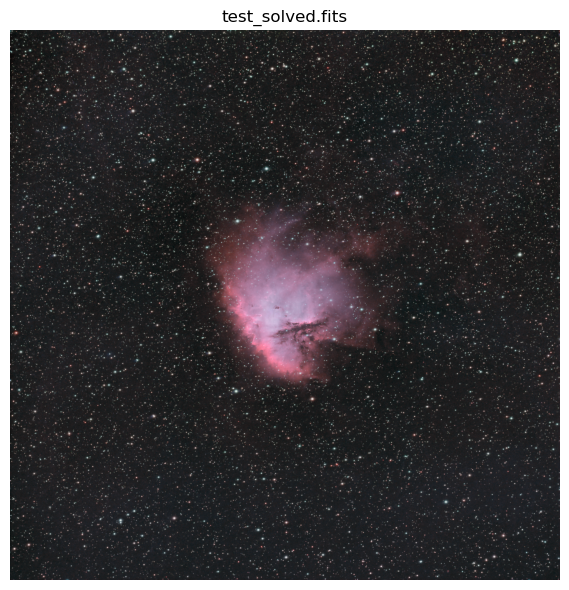

In [2]:
IMAGE_PATH = "data/test_solved.fits"

from astropy.io import fits
from astropy.wcs import WCS
import warnings
from astropy.wcs import FITSFixedWarning

with fits.open(IMAGE_PATH) as hdul:
    img = np.array(hdul[0].data / 255.0, dtype=np.float32)
    #make sure color channel is the last dimension (H, W, C) for WCS
    if img.ndim == 3 and img.shape[0] in (3, 4):
        img = np.transpose(img, (1, 2, 0))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FITSFixedWarning)
        wcs = WCS(hdul[0].header, naxis=2)  # naxis=2: always a clean 2D RA/Dec WCS
    print(f"✓ WCS loaded  (naxis={wcs.naxis})")

print(f"Shape: {img.shape}  dtype: {img.dtype}")

plt.figure(figsize=(8, 6))
plt.imshow(img,cmap='gray' if img.ndim == 2 else None)
plt.axis('off')
plt.title(IMAGE_PATH)
plt.tight_layout()
plt.show()

## 2. Detect sources

Key parameters:
- `threshold_sigma` — detection sensitivity (lower = more sources, more noise)
- `fwhm_scale_stellar` — sources with `fwhm < psf_fwhm × scale` are classified as stars
- `max_ellipticity_stellar` — stars must be rounder than this

In [3]:
detector = SEPDetector(
    threshold_sigma=3.0,
    fwhm_scale_stellar=20,
    max_ellipticity_stellar=0.3,
)

catalog = detector.detect(img, wcs=wcs)
print(catalog)
print(f"  Stars:    {len(catalog.stars)}")
print(f"  Extended: {len(catalog.extended)}")
print(f"  PSF FWHM: {catalog.psf_fwhm:.2f} px")

SourceCatalog(20134 sources: 17775 stellar, 2359 extended, psf_fwhm=2.37px)
  Stars:    17775
  Extended: 2359
  PSF FWHM: 2.37 px


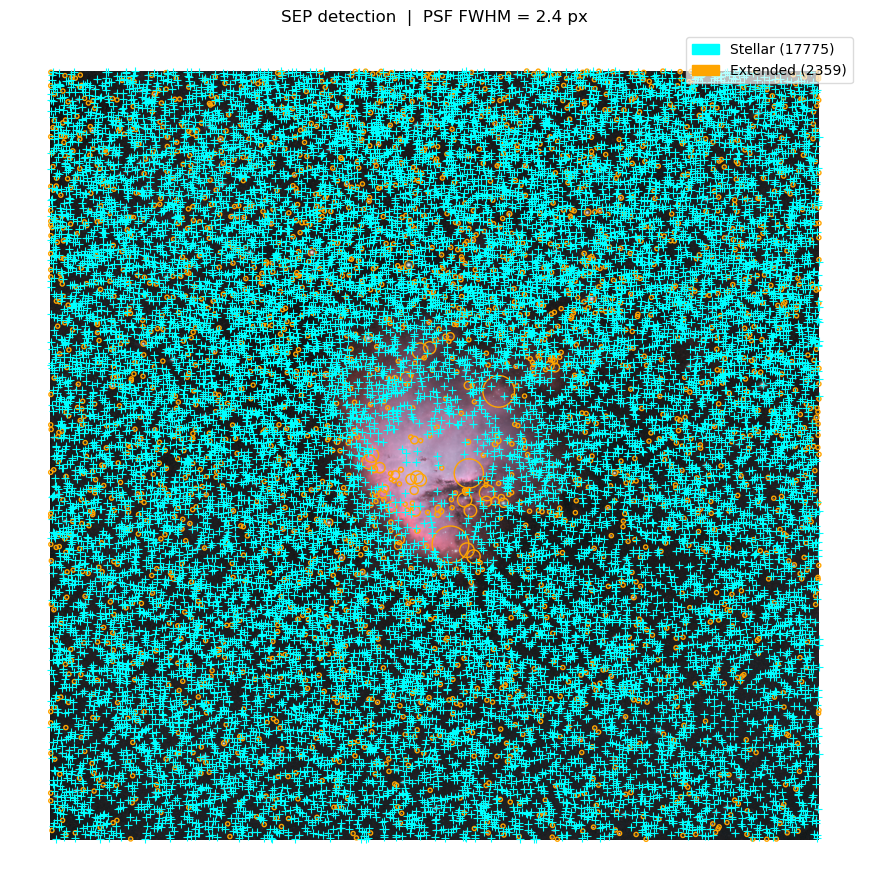

In [4]:
import matplotlib.patches as mpatches
%matplotlib inline
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(img, cmap='gray' if img.ndim == 2 else None, origin='upper')

for src in catalog.stars:
    ax.plot(src.x, src.y, '+', color='cyan', markersize=6, markeredgewidth=0.8)

for src in catalog.extended:
    r = max(src.fwhm, 8)
    ax.add_patch(plt.Circle((src.x, src.y), r, color='orange', fill=False, linewidth=1.0))

ax.legend(handles=[
    mpatches.Patch(color='cyan',   label=f'Stellar ({len(catalog.stars)})'),
    mpatches.Patch(color='orange', label=f'Extended ({len(catalog.extended)})'),
], loc='upper right', framealpha=0.7)
ax.set_title(f"SEP detection  |  PSF FWHM = {catalog.psf_fwhm:.1f} px")
ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

df = pd.DataFrame([
    dict(x=s.x, y=s.y, ra=s.ra, dec=s.dec,
         flux=s.flux, fwhm=s.fwhm, ellipticity=s.ellipticity, stellar=s.is_stellar)
    for s in catalog.sources
]).sort_values("flux", ascending=False)

df.head(20)

,x,y,ra,dec,flux,fwhm,ellipticity,stellar
13765,1560.320216,1847.554667,13.170393,56.393448,1069.041138,71.432207,0.511842,False
11893,1632.026280,1570.816358,13.043260,56.595924,1052.895264,57.066103,0.566337,False
10219,1748.633678,1250.720545,12.848578,56.827879,377.825714,61.737307,0.637502,False
9690,2780.203463,1224.910328,11.441090,56.774543,280.189331,16.523450,0.243536,True
6090,1398.995269,756.312877,13.272753,57.218456,263.694122,17.153907,0.363690,False
14171,1232.875323,1969.677015,13.624131,56.320762,236.737549,16.019270,0.288835,True
7217,2111.794485,888.329748,12.308053,57.074670,233.349350,16.435472,0.399340,False
5626,1020.441283,707.454935,13.790160,57.275898,226.928818,15.942053,0.312840,False
8414,1240.863106,1041.811743,13.520188,57.013996,219.568817,16.529740,0.387770,False
1444,2762.056354,164.274109,11.311018,57.566651,214.240875,14.248367,0.226038,True


## 3. Gaia cross-match

Query Gaia DR3 for the field, then match each detected source to its nearest Gaia neighbour within `max_sep_arcsec`.

In [6]:
from catalog import query_gaia, crossmatch

# Field info — pull from WCS or hardcode from your plate solve result
FIELD_RA    = 13.2153   # degrees
FIELD_DEC   = 56.6571   # degrees
FIELD_RADIUS = 2     # degrees — adjust to your image FOV
PIXSCALE    = 2.697     # arcsec/pixel

gaia_df = query_gaia(FIELD_RA, FIELD_DEC, radius=FIELD_RADIUS * 1.05)
print(f"Gaia sources in field: {len(gaia_df)}")
gaia_df.head(10)

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
INFO: Query finished. [astroquery.utils.tap.core]
Gaia sources in field: 765947


,source_id,ra,dec,phot_g_mean_mag,parallax,pmra,pmdec
0,418551920284673408,10.127242,56.537189,1.942524,14.090976,49.125646,-31.595374
1,425040000962559616,12.285227,57.812728,3.320067,168.832160,1078.609167,-551.133420
2,418414069011230720,11.321324,55.221373,5.411243,9.234226,-29.934867,-5.616373
3,424376445693261696,14.054396,57.996489,5.739205,4.839448,41.265135,-15.634082
4,412052432178880000,16.751496,56.934488,6.060689,9.751203,94.426902,-108.856428
5,423890702073141504,12.307781,57.074985,6.096333,2.335040,-2.972550,-8.731386
6,423917159069394560,15.532308,56.328622,6.411534,5.317859,45.148548,-11.573896
7,417670730434568192,11.562801,55.305363,6.481386,5.967196,10.192677,-4.113285
8,424224433906835456,13.790713,57.276128,6.597316,0.845381,-1.872529,-3.312301
9,423959077951794816,15.221485,56.612542,6.606388,1.106853,1.646567,-0.630353


In [7]:
matches = crossmatch(catalog, gaia_df, pixscale=PIXSCALE, max_sep_arcsec=10.0)

n_matched = matches["gaia_matched"].sum()
print(f"Matched:   {n_matched} / {len(matches)} sources")
print(f"Unmatched: {len(matches) - n_matched}")

matches[matches["gaia_matched"]].sort_values("gaia_g_mag").head(20)

Matched:   19987 / 20134 sources
Unmatched: 147


,x,y,flux,fwhm,fwhm_arcsec,ellipticity,is_stellar,ra,dec,sep_arcsec,gaia_matched,gaia_source_id,gaia_ra,gaia_dec,gaia_g_mag,gaia_parallax,gaia_pmra,gaia_pmdec
7217,2111.794485,888.329748,233.349350,16.435472,44.326468,0.399340,False,12.308053,57.074670,1.252325,True,423890702073141504,12.307781,57.074985,6.096333,2.335040,-2.972550,-8.731386
5626,1020.441283,707.454935,226.928818,15.942053,42.995716,0.312840,False,13.790160,57.275898,1.358648,True,424224433906835456,13.790713,57.276128,6.597316,0.845381,-1.872529,-3.312301
9690,2780.203463,1224.910328,280.189331,16.523450,44.563746,0.243536,True,11.441090,56.774543,1.426455,True,424528384454737408,11.441494,56.774871,6.837755,1.045871,2.431609,-3.461811
14171,1232.875323,1969.677015,236.737549,16.019270,43.203971,0.288835,True,13.624131,56.320762,5.441407,True,423773604081990912,13.625649,56.319506,7.100274,7.170773,69.743349,-17.601583
6090,1398.995269,756.312877,263.694122,17.153907,46.264086,0.363690,False,13.272753,57.218456,2.748630,True,424215092360097536,13.273522,57.219096,7.240397,3.173153,12.376722,-13.183669
3530,670.512348,441.404715,178.278061,13.621223,36.736438,0.245164,True,14.250313,57.492364,1.579954,True,424324420747669632,14.251069,57.492198,7.562804,3.754686,8.584989,-19.801858
5624,779.514776,709.642043,202.974442,14.107065,38.046753,0.280499,True,14.123292,57.286446,3.208980,True,424227908543866624,14.124941,57.286454,7.633570,2.103356,-4.858230,-4.496117
18361,895.427317,2662.323976,149.344818,12.720319,34.306700,0.246390,True,14.139715,55.820352,5.829420,True,423569404160510976,14.141707,55.819182,7.734799,2.105088,-5.350611,3.179104
12904,1087.244017,1761.621231,172.758484,13.979551,37.702850,0.317821,False,13.800487,56.484072,5.007196,True,423799751837695872,13.802278,56.483094,7.785288,3.872421,12.061652,9.556553
8414,1240.863106,1041.811743,219.568817,16.529740,44.580710,0.387770,False,13.520188,57.013996,2.068831,True,424203856730139648,13.521233,57.014076,7.854159,NaN,NaN,NaN


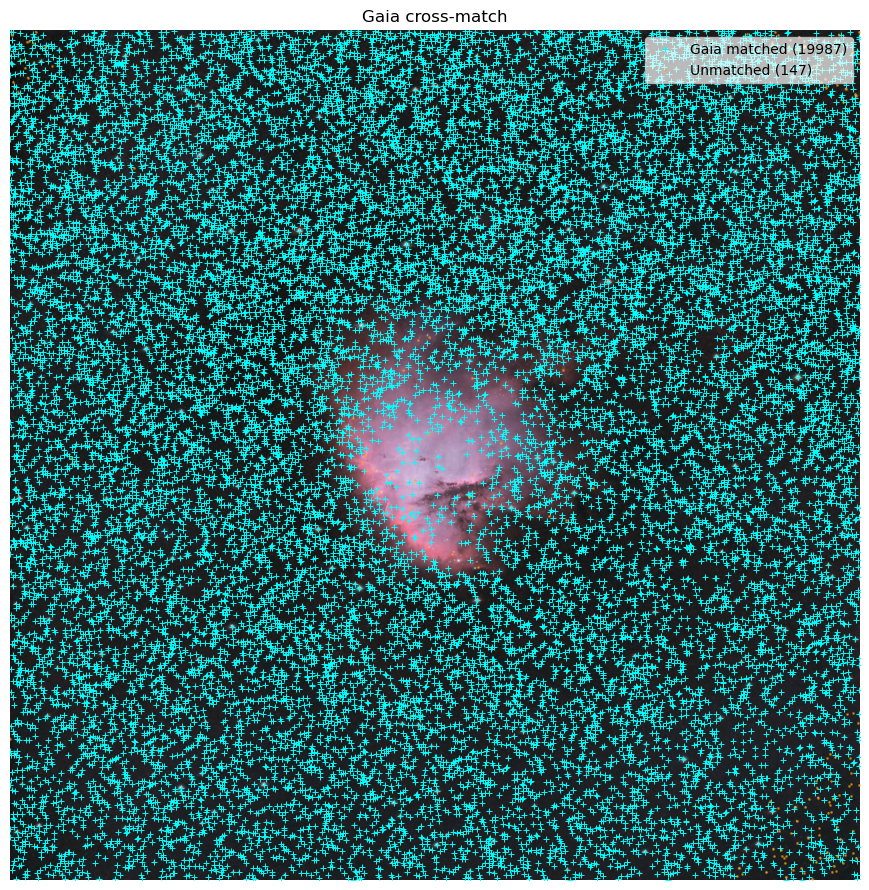

In [8]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(img, cmap="gray" if img.ndim == 2 else None, origin="upper")

matched   = matches[matches["gaia_matched"]]
unmatched = matches[~matches["gaia_matched"]]

ax.plot(matched["x"],   matched["y"],   "+", color="cyan",  markersize=5, markeredgewidth=0.7, label=f"Gaia matched ({len(matched)})")
ax.plot(unmatched["x"], unmatched["y"], ".", color="orange", markersize=2, alpha=0.5,           label=f"Unmatched ({len(unmatched)})")

ax.legend(loc="upper right", framealpha=0.7)
ax.set_title("Gaia cross-match")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Save catalog

In [9]:
CACHE_PATH = "data/matches.parquet"
matches.to_parquet(CACHE_PATH, index=False)
print(f"Saved {len(matches)} sources → {CACHE_PATH}")

Saved 20134 sources → data/matches.parquet
